In [1]:
from data.weather_fetch import write_query_config, fetch_and_save
from data.preprocess_311 import preprocess_311

In [3]:
import os
outs = preprocess_311(['csv_data/' + f for f in os.listdir('csv_data')])

Reading csv_data/311_City_Service_Requests_in_2022.csv …
Reading csv_data/311_City_Service_Requests_in_2024.csv …
Reading csv_data/311_City_Service_Requests_in_2025.csv …
Reading csv_data/All_Service_Requests_-_2021.csv …
Reading csv_data/All_Service_Requests_-_2023.csv …
  Combined: 17,405 Pothole rows across wards: ['Null', 'Ward 1', 'Ward 2', 'Ward 3', 'Ward 4', 'Ward 5', 'Ward 6', 'Ward 7', 'Ward 8']
  Wrote data/311_data/null_potholes_20210101_20251231.parquet  (260 rows)  centroid=(38.917929, -77.014602)
  Wrote data/311_data/ward1_potholes_20210101_20251231.parquet  (1,419 rows)  centroid=(38.926030, -77.031193)
  Wrote data/311_data/ward2_potholes_20210101_20251231.parquet  (2,085 rows)  centroid=(38.904732, -77.042980)
  Wrote data/311_data/ward3_potholes_20210101_20251231.parquet  (3,192 rows)  centroid=(38.943303, -77.078361)
  Wrote data/311_data/ward4_potholes_20210101_20251231.parquet  (2,315 rows)  centroid=(38.960461, -77.030698)
  Wrote data/311_data/ward5_potholes_202

In [4]:
# inspect outs 
wards = [f'ward{i}' for i in range(1, 9)]
for ward in wards: 
    lat, lon = outs[ward][1], outs[ward][2]
    # write a query config 
    query_config = write_query_config(ward, lat, lon, '2020-06-01', '2025-12-31')
    _, _ = fetch_and_save(query_config)

Config written → data/weather_query_configs/weather_ward1_20200601_20251231.json
Fetching from Open-Meteo API for ward1 …
  Coordinates : (38.92603046577167, -77.03119300595489)
  Date range  : 2020-06-01 → 2025-12-31
Saved  data/weather_cache/weather_ward1_20200601_20251231.parquet  (48,960 rows)
Saved  data/weather_cache/weather_ward1_20200601_20251231_metadata.json
Config written → data/weather_query_configs/weather_ward2_20200601_20251231.json
Fetching from Open-Meteo API for ward2 …
  Coordinates : (38.904732202853715, -77.04297967810552)
  Date range  : 2020-06-01 → 2025-12-31
Saved  data/weather_cache/weather_ward2_20200601_20251231.parquet  (48,960 rows)
Saved  data/weather_cache/weather_ward2_20200601_20251231_metadata.json
Config written → data/weather_query_configs/weather_ward3_20200601_20251231.json
Fetching from Open-Meteo API for ward3 …
  Coordinates : (38.94330329516604, -77.07836148511278)
  Date range  : 2020-06-01 → 2025-12-31
Saved  data/weather_cache/weather_ward3

In [1]:
# visualize the entire pothole requests data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_parquet('data/311_data/ward3_potholes_20210101_20251231.parquet')
df.head()

,ADDDATE,WARD,SERVICECODEDESCRIPTION
0,2022-01-01 18:00:40+00:00,Ward 3,Pothole
1,2022-01-02 15:26:46+00:00,Ward 3,Pothole
2,2022-01-02 16:58:07+00:00,Ward 3,Pothole
3,2022-01-02 16:58:49+00:00,Ward 3,Pothole
4,2022-01-05 18:44:40+00:00,Ward 3,Pothole


In [2]:
len(pd.to_datetime(df['ADDDATE']).dt.date.unique())

1249

Text(0.5, 1.0, 'Pothole Requests Over Time')

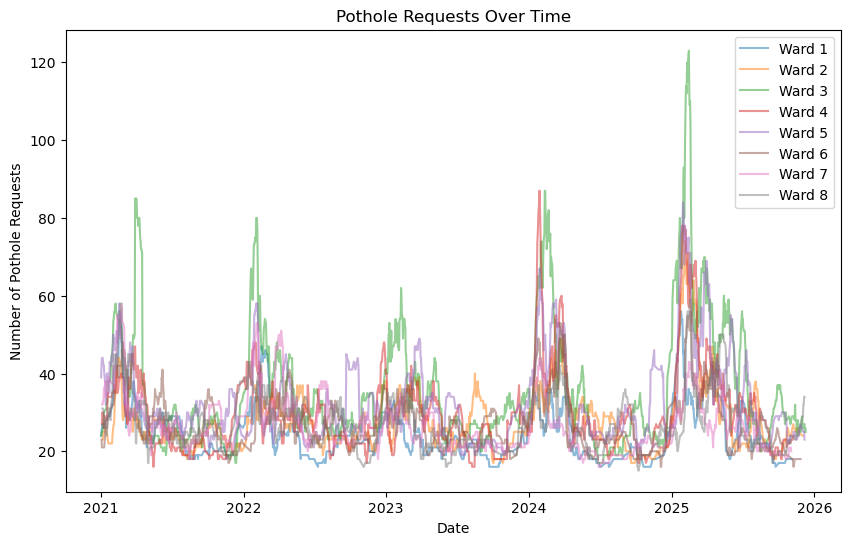

In [3]:
ward_parquets = [f'data/311_data/ward{i}_potholes_20210101_20251231.parquet' for i in range(1, 9)]
def process_pothole_data(df: pd.DataFrame) -> pd.DataFrame:
    df = df.sort_values("ADDDATE")
    df['DATE'] = pd.to_datetime(df['ADDDATE']).dt.date
    potholes_daily = df.groupby('DATE').size()
    return potholes_daily

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)
for idx, f in enumerate(ward_parquets):
    ward_name = f'Ward {idx + 1}'
    df = pd.read_parquet(f)
    potholes_daily = process_pothole_data(df)
    ax.plot(potholes_daily.index, potholes_daily.rolling(15).sum().shift(-14), 
            label=ward_name, alpha=0.5)
ax.legend()
plt.xlabel('Date')
plt.ylabel('Number of Pothole Requests')
plt.title('Pothole Requests Over Time')

Text(0.5, 1.0, 'Pothole Requests Over Time')

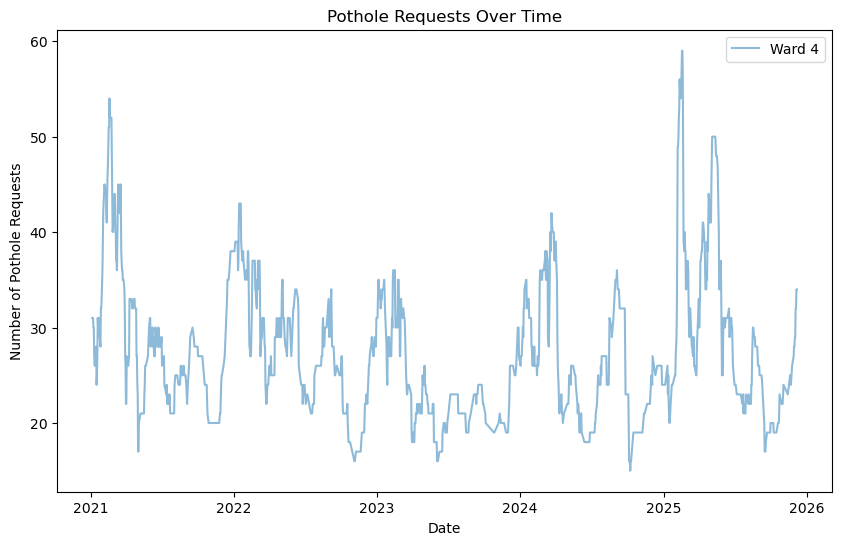

In [4]:
# ward 3 trend 
idx = 3 

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

ward_name = f'Ward {idx + 1}'
df = pd.read_parquet(f)
potholes_daily = process_pothole_data(df)
ax.plot(potholes_daily.index, potholes_daily.rolling(15).sum().shift(-14), 
        label=ward_name, alpha=0.5)
ax.legend()
plt.xlabel('Date')
plt.ylabel('Number of Pothole Requests')
plt.title('Pothole Requests Over Time')

In [19]:
# make an autocorrelation plot 
from statsmodels.graphics.tsaplots import plot_acf
from modeling.data.load import load_311
from omegaconf import OmegaConf
from modeling.data.master import build_daily
from modeling.features import assemble_features
from modeling.split import make_split
from modeling.models import build_model
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima

In [20]:
# get data and featurize 

# 1. read a base config 
cfg = OmegaConf.load('configs/first_try.yaml')
cfg.ward.raw_311 = 'data/311_data/ward3_potholes_20210101_20251231.parquet'
cfg.ward.weather_cache = 'data/weather_cache/weather_ward3_20200601_20251231.parquet'

In [21]:
# reset features 
cfg.features = {
  "d": 7,
  "d_p": 15,
  "l_p": 10,
  "d_s": 15,
  "l_s": 0,
  "d_f": 15,
  "l_f": 0,
  "k_AR": 0
}

In [22]:
pothole_df, weather_df = build_daily(cfg) # build the daily series 
feat_df = assemble_features(pothole_df, weather_df, cfg.features) 

[assemble_features] kept 1819/1826 rows (99.6%) after dropping NaNs


<Axes: >

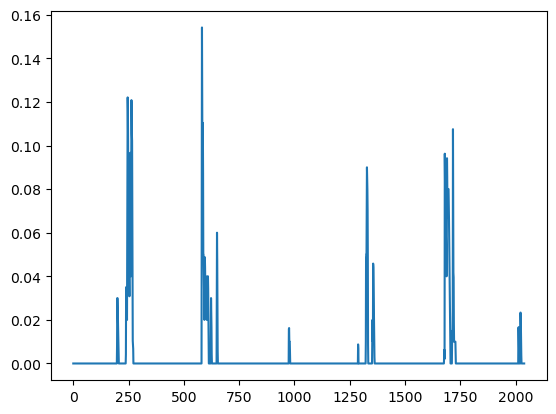

In [23]:
weather_df['daily_snow'].plot()

In [24]:
cfg.split.method = 'temporal'
cfg.split.val_frac = 0.15
cfg.split.test_frac = 0.15
feat_df = make_split(feat_df, cfg.split) # split the data into train, val, and test sets
feature_cols = [c for c in feat_df.columns if c not in ("date", "Y", "split")]
train_df = feat_df[feat_df["split"] == "train"] # get the train set
val_df = feat_df[feat_df["split"] == "val"] # get the val set
train_val_df = feat_df[feat_df["split"].isin(["train", "val"])] # get the train and val set

In [34]:
cfg.model._target_= 'modeling.models.gbm.XGBModel'
cfg.model.name = 'xgb'
cfg.model.n_estimators = 100
cfg.model.learning_rate = 0.1
cfg.model.max_depth = 8
cfg.model.objective= "count:poisson"
cfg.features.k_AR = 0
cfg.model

{'_target_': 'modeling.models.gbm.XGBModel', 'name': 'xgb', 'alpha': 1.0, 'n_estimators': 100, 'learning_rate': 0.1, 'max_depth': 8, 'objective': 'count:poisson'}

In [35]:
cfg.features

{'d': 7, 'd_p': 15, 'l_p': 10, 'd_s': 15, 'l_s': 0, 'd_f': 15, 'l_f': 0, 'k_AR': 0}

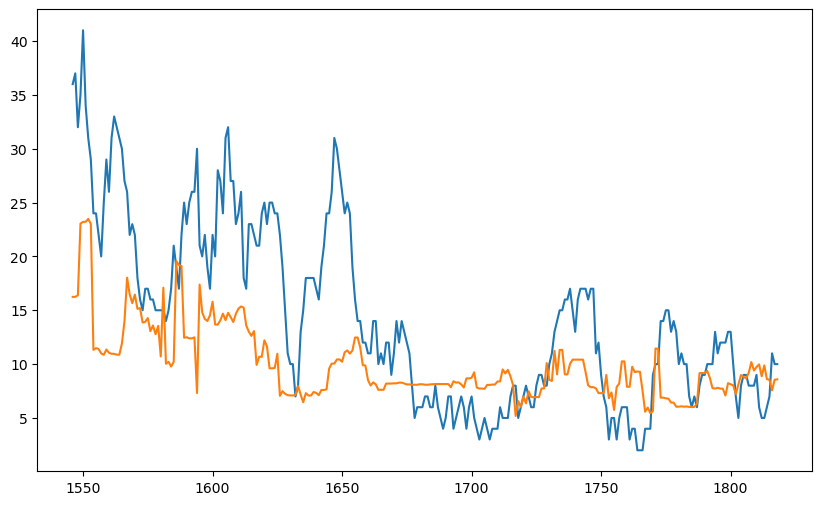

In [36]:
train_val_df = feat_df[feat_df["split"].isin(["train", "val"])] # get the train and val set
X_tv = train_val_df[feature_cols]
y_tv = train_val_df["Y"] # get the target for the train and val set
model = build_model(cfg.model) # build the model
# model.fit(X_tv, y_tv) # fit the model on the train and val set
model.fit(X_tv, y_tv)
# predict on test set
test_df = feat_df[feat_df["split"] == "test"] # get the test set
X_test = test_df[feature_cols]
y_test = test_df["Y"] # get the target for the test set

# plot the predictions 
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)
ax.plot(y_test.index, y_test.values, label='True')
ax.plot(y_test.index, model.predict(X_test), label='Predicted')
plt.show()

# Sarimax

In [84]:
y_tv_preds = model.predict(X_tv)
residuals = y_tv.values - y_tv_preds
auto_arima(np.array(residuals), trace=True)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=5677.542, Time=0.91 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=6949.475, Time=0.06 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=5697.578, Time=0.06 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=6206.030, Time=0.33 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=6951.870, Time=0.02 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=5689.604, Time=0.43 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=5691.035, Time=0.64 sec
 ARIMA(3,0,2)(0,0,0)[0] intercept   : AIC=5632.174, Time=1.26 sec
 ARIMA(3,0,1)(0,0,0)[0] intercept   : AIC=5693.208, Time=0.11 sec
 ARIMA(4,0,2)(0,0,0)[0] intercept   : AIC=5651.083, Time=0.49 sec
 ARIMA(3,0,3)(0,0,0)[0] intercept   : AIC=5650.897, Time=0.55 sec
 ARIMA(2,0,3)(0,0,0)[0] intercept   : AIC=5663.160, Time=0.45 sec
 ARIMA(4,0,1)(0,0,0)[0] intercept   : AIC=5677.637, Time=0.25 sec
 ARIMA(4,0,3)(0,0,0)[0] intercept   : AIC=5651.070, Time=0.70 sec
 ARIMA(3,0,2)(0,0,0)[0]          

,order,"(3, ...)"
,seasonal_order,"(0, ...)"
,start_params,None
,method,'lbfgs'
,maxiter,50
,suppress_warnings,True
,out_of_sample_size,0
,scoring,'mse'
,scoring_args,{}
,trend,None
,with_intercept,False


In [85]:
from statsmodels.tsa.api import ARIMA
arma_params = (3,0,2)
s_params = (1,1,1,7)


In [86]:
sarima_model = ARIMA(residuals, order=arma_params,\
     seasonal_order=s_params)

In [87]:
results = sarima_model.fit()
results.summary()

/Users/shashanksule/miniforge3/envs/erdos_ds_environment/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Users/shashanksule/miniforge3/envs/erdos_ds_environment/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                     
=========================================================================================
Dep. Variable:                                 y   No. Observations:                 1538
Model:             ARIMA(3, 0, 2)x(1, 1, [1], 7)   Log Likelihood               -2763.384
Date:                           Thu, 19 Mar 2026   AIC                           5542.768
Time:                                   12:22:20   BIC                           5585.437
Sample:                                        0   HQIC                          5558.647
                                          - 1538                                         
Covariance Type:                             opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2088      0.417      0.501      0.616      -0.608       1.026
ar.L2          0.2512      0.413      0.608      0.543      -0.558       1.061
ar.L3          0.2370      0.148      1.597      0.110      -0.054       0.528
ma.L1          0.4983      0.419      1.189      0.235      -0.323       1.320
ma.L2          0.2023      0.213      0.948      0.343      -0.216       0.621
ar.S.L7       -0.3301      0.018    -18.254      0.000      -0.366      -0.295
ma.S.L7       -0.9995      0.137     -7.269      0.000      -1.269      -0.730
sigma2         2.1057      0.285      7.393      0.000       1.547       2.664
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):               729.79
Prob(Q):                              0.96   Prob(JB):                         0.00
Heteroskedasticity (H):               0.85   Skew:                             0.13
Prob(H) (two-sided):                  0.07   Kurtosis:                         6.37
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [89]:
y_pred = results.forecast(steps = 271) + model.predict(X_test)

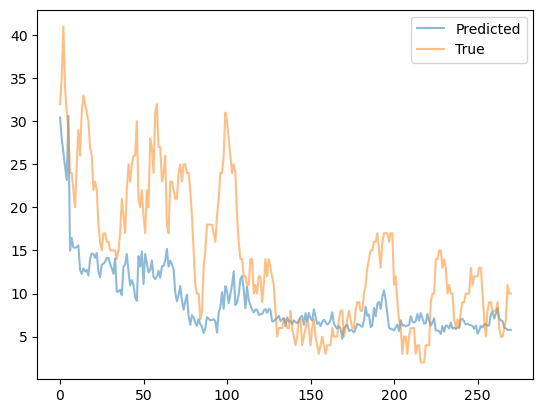

In [90]:
plt.plot(y_pred, label='Predicted', alpha=0.5)
plt.plot(y_test.values, label='True', alpha=0.5)
plt.legend()    
plt.show()


Text(0.5, 0, 'Predicted')

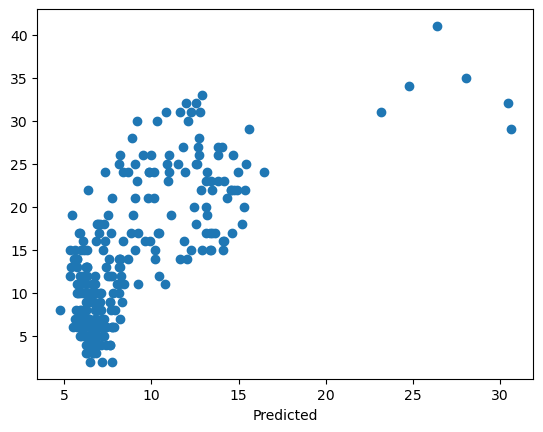

In [91]:
plt.scatter(y_pred, y_test.values)
plt.xlabel('Predicted')

In [77]:
r_squared = np.mean((y_pred-y_pred.mean())*(y_test.values-y_test.values.mean()))/np.std(y_test.values)*np.std(y_pred)

In [78]:
r_squared

np.float64(4.256135640972792)

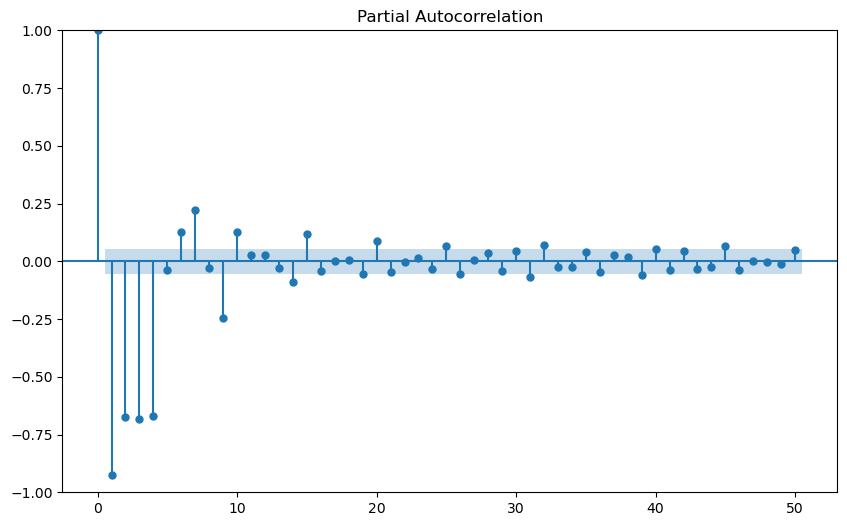

In [92]:
from statsmodels.graphics.tsaplots import plot_pacf
import numpy as np
def difference_operator(time_series: np.ndarray, n: int = 1) -> np.ndarray:
    return np.diff(time_series, n=n)

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)
y = difference_operator(train_df.Y.values, 10)
plot_pacf(y, lags=50, ax=ax)
plt.show()


In [94]:
from statsmodels.tsa.stattools import adfuller

adfuller(train_df.Y.values)

(np.float64(-3.9019608151292418),
 np.float64(0.0020204638830120967),
 22,
 1252,
 {'1%': np.float64(-3.4355838322867998),
  '5%': np.float64(-2.863851267837805),
  '10%': np.float64(-2.5680005460145554)},
 np.float64(5507.472009039241))

In [ ]:
# fit a sarima model 
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(potholes_daily, order=(1, 1, 1), seasonal_order=(1, 1, 1, 7))
results = model.fit()
print(results.summary())
